In [ ]:
import os 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import flopy as fp

In [ ]:
modelname = 'webinar'
modelws = './webinar'
path = os.getcwd()
plt.rcParams['figure.figsize'] = (5, 5)
plt.rcParams["figure.autolayout"] = True

In [ ]:
# Model parameters

# Grid parameters
Lx = 5000
Ly = 5000
ncol = 100
nrow = 100
delr = Lx / ncol
delc = Ly / nrow

# Layer parameters
nlay = 4
top = 60
botm = [40, 35, 15, 0]

# Aquifer parameters
k_h = [20, 0.01, 10, 5]
k_v = [20, 0.01, 10, 5]
porosity = 0.3


In [ ]:
# Boundary conditions
head_river = 58
Q_well = -3000
Recharge = 5e-4

In [ ]:
# Create the Simulation
exe_name = "mf6.exe"
sim = fp.mf6.MFSimulation(sim_name=modelname, 
                          version='mf6',
                          exe_name=exe_name,
                          sim_ws=modelws,
                          )

In [ ]:
# Time discretization
tdis_rc = [(1.0, 1, 1.0)]
tdis = fp.mf6.ModflowTdis(
    sim,
    time_units="DAYS",
    perioddata=tdis_rc,
)

In [ ]:
# Iterative model solution
ims = fp.mf6.ModflowIms(sim, 
                        complexity='SIMPLE',
                        inner_dvclose=1e-6,
)

In [ ]:
# Groundwater Flow Model
gwf = fp.mf6.ModflowGwf(sim, 
                        modelname=modelname, 
                        model_nam_file=f"{modelname}.nam",
                        save_flows=True)

In [ ]:
# ADD PACKAGES 

# Discretization
dis = fp.mf6.ModflowGwfdis(gwf,
                           length_units='METERS', 
                           nlay=nlay, 
                           nrow=nrow, 
                           ncol=ncol, 
                           delr=delr, 
                           delc=delc,
                           top=top, 
                           botm=botm,
                           )


In [ ]:
# Node property flow package
npf = fp.mf6.ModflowGwfnpf(gwf, 
                           save_specific_discharge=True,
                           icelltype=[1, 0, 0, 0], # 1 = confined, 0 = unconfined
                           k = k_h, 
                           k33 = k_v,
                           )

In [ ]:
# Initial Conditions
ic = fp.mf6.ModflowGwfic(gwf, 
                         strt=head_river,
                         )

In [ ]:
# Specified Head Package
# Creates a vertical wall of constant head (58m) along the entire right edge of your model in the top layer.
# Represents a boundary condition like a river that maintains a constant water level.
# These cells will supply or remove water as needed to maintain the 58m head.
# Acts as an infinite source/sink of water

chd_spd = []
for r in range(nrow):
    chd_spd.append([(0, r, ncol - 1), head_river])

chd = fp.mf6.ModflowGwfchd(gwf, 
                           stress_period_data=chd_spd,
)

In [ ]:
# Recharge Package
rch = fp.mf6.ModflowGwfrcha(gwf, 
                           recharge=Recharge,
                           pname = 'rch'
)    

In [ ]:
# Well Package
well_row_col = [[40, 90], [50, 90], [60, 90]]
well_spd = []
for rc in well_row_col:
    r = rc[0]
    c = rc[1]
    well_spd.append([(2, r, c), Q_well])

wel = fp.mf6.ModflowGwfwel(gwf,
                        stress_period_data=well_spd,
)

In [ ]:
# Output control
oc = fp.mf6.ModflowGwfoc(gwf,
                         head_filerecord=f"{modelname}.hds",
                         budget_filerecord=f"{modelname}.cbb",
                         saverecord=[('HEAD', 'ALL'), ('BUDGET', 'ALL')],
                         printrecord=[('HEAD', 'LAST'), ('BUDGET', 'LAST')]
)

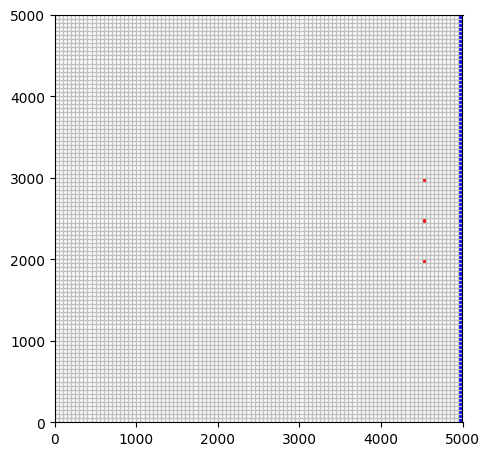

In [ ]:
# Check input
pmv = fp.plot.PlotMapView(model=gwf)
pmv.plot_bc('CHD', color='blue')
pmv.plot_bc('WEL', plotAll=True, color='red')
pmv.plot_grid(colors='silver', lw=1)

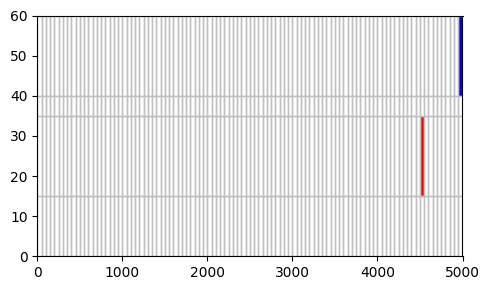

In [ ]:
plt.figure(figsize=(5, 3))
pxs = fp.plot.PlotCrossSection(model=gwf, line={'row': 50})
pxs.plot_bc('CHD', color='blue')
pxs.plot_bc('WEL', color='red')
pxs.plot_grid(colors='silver', lw=1)


In [ ]:
# Solve the model
sim.write_simulation()
sim.run_simulation()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model webinar...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package ic...
    writing package chd_0...
INFORMATION: maxbound in ('', 'chd', 'dimensions') changed to 100 based on size of stress_period_data
    writing package rch...
    writing package wel_0...
INFORMATION: maxbound in ('', 'wel', 'dimensions') changed to 3 based on size of stress_period_data
    writing package oc...
FloPy is using the following executable to run the model: ..\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.7.0 02/05/2026

   MODFLOW 6 compiled Feb 05 2026 22:36:44 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.6.0
                             Bui

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model webinar...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package ic...
    writing package chd_0...
INFORMATION: maxbound in ('', 'chd', 'dimensions') changed to 100 based on size of stress_period_data
    writing package rch...
    writing package wel_0...
INFORMATION: maxbound in ('', 'wel', 'dimensions') changed to 3 based on size of stress_period_data
    writing package oc...
FloPy is using the following executable to run the model: ..\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.7.0 02/05/2026

   MODFLOW 6 compiled Feb 05 2026 22:36:44 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.6.0
                             Bui

(True, [])

In [ ]:
# Read Heads
fname = os.path.join(modelws, f'{modelname}.hds')
hobj = fp.utils.HeadFile(fname)
head = hobj.get_data(totim=1.0) # Get the head data for the first time step (totim=1.0) and store it in the variable 'head' as a 3D array (nlay, nrow, ncol).
head_lay2 = hobj.get_data(mflay=2) # Extract the head data for layer 2 (index 1) and store it in the variable 'head_lay2' as a 2D array (nrow, ncol).
print('max head in layer 2:', np.max(head_lay2))
print('min head in layer 2:', np.min(head_lay2))



max head in layer 2: 65.99296539065013
min head in layer 2: 50.68001233781605


Text(0.5, 1.0, 'Head Contours for Layer 2')

Text(0.5, 1.0, 'Head Contours for Layer 2')

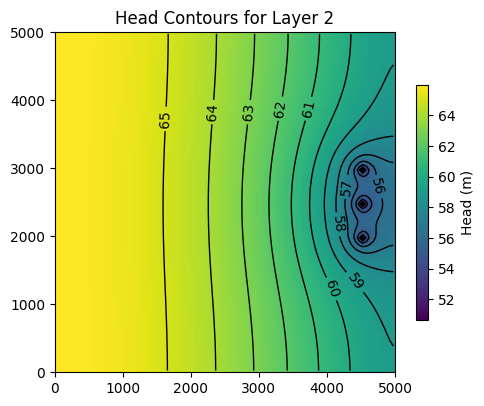

In [ ]:
# Contour Plot
pmv = fp.plot.PlotMapView(model=gwf)
qm = pmv.plot_array(head_lay2)
plt.colorbar(qm, shrink=0.5, label='Head (m)')
cs = pmv.contour_array(head_lay2, levels=range(50, 70), linewidths=1, colors='k') 
plt.clabel(cs, fmt='%1.0f')
plt.title('Head Contours for Layer 2')

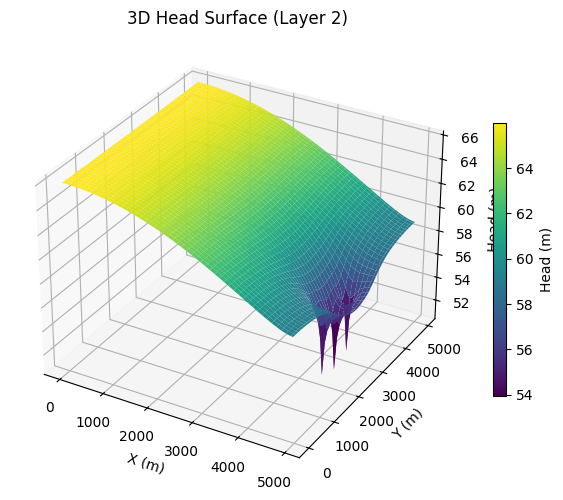

In [ ]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

x = np.arange(ncol) * delr
y = np.arange(nrow) * delc
X, Y = np.meshgrid(x, y)

surf = ax.plot_surface(X, Y, head_lay2, cmap='viridis', linewidth=0, antialiased=True)
fig.colorbar(surf, shrink=0.6, label='Head (m)')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Head (m)')
ax.set_title('3D Head Surface (Layer 2)')
plt.show()

In [ ]:
# Water Balance 
fname = os.path.join(modelws, f"{modelname}.cbb")
cbb = fp.utils.CellBudgetFile(fname, precision='double')

In [ ]:
# Read Flow and Quiver Plot
spdis = cbb.get_data(text='DATA-SPDIS')[0] 
qx = spdis["qx"].reshape((nlay, nrow, ncol))
qy = spdis["qy"].reshape((nlay, nrow, ncol)) 

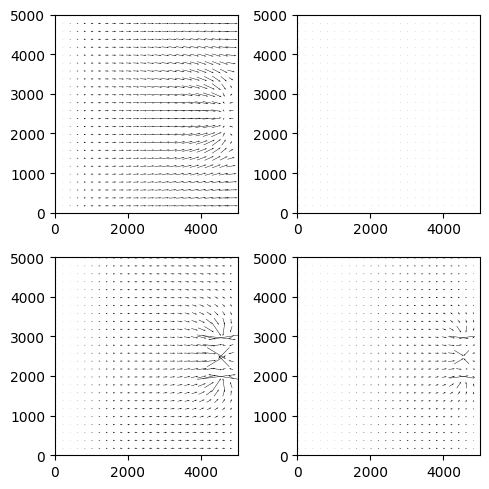

In [ ]:
for l in range(nlay):
    ax = plt.subplot(2, 2, l+1)
    pmv = fp.plot.PlotMapView(model=gwf, ax=ax, layer=l)
    quiver = pmv.plot_vector(qx, 
                        qy, 
                        scale=1,
                        istep=4,
                        jstep=4,
                        color="k",
                        )
    plt.xlim = (Lx / 2, Lx)
    plt.title = (f"Layer{l}")

plt.tight_layout()

In [ ]:
# 1. Function to create N particle positions on a circle​
def PointsOnCircle(r=10, N=12): # default is 10 m radius and 12 particles​
    rv = [2 * np.pi /N *n_i for n_i in range(0,N)] # N angles equally spaced around the circle​
    return np.vstack((r * np.cos(rv), r * np.sin(rv))).T # convert to x and y coordinates and transpose to get N rows of (x,y) pairs​.

pr = PointsOnCircle()
# 2. Define particle starting points inside well cells​

localx = []  # particle local coordinates inside MF cell​
localy = []
localz = []
partlocs = [] # list of (layer,row,col) for each particle​

for rc in well_row_col: # loop over all well cells​
    r = rc[0] # row index of the well cell​
    c = rc[1] # column index of the well cell​
    for pr_i in pr: # pr_i is one (x,y) coordinate from the circle around the well.​
        lx = (delc / 2 + pr_i[0]) / delc # compute local x coordinate of the particle in the cell.​
        ly = (delr / 2 + pr_i[1]) / delr
        lz = 0.5 # vertical position halfway in the layer​
        partlocs.append((2,r,c)) # particles are in layer 2, row r,column c.
        localx.append(lx)
        localy.append(ly)
        localz.append(lz)

particledata = fp.modpath.ParticleData(partlocs, 
                                       structured=True,
                                       localx=localx,
                                       localy=localy,
                                       localz=localz)

pg = fp.modpath.ParticleGroup(particledata=particledata) #create a particle group with the particle data​

mp = fp.modpath.Modpath7(modelname=f"{modelname}_abs_wells_bw", #build  MODPATH 7 model with the GWF​
                         model_ws=modelws,
                         flowmodel=gwf,
                         exe_name="mpath7")  # mpath7 executable - ensure it's installed

mpbas = fp.modpath.Modpath7Bas(mp,porosity=0.3) # set the porosity for the MODPATH model​

mpsim = fp.modpath.Modpath7Sim(mp, 
                               particlegroups=pg,
                               weaksourceoption="pass_through", # particles that enter a well cell will pass through ​
                               stoptime = 100*365.,# stop time of 100 years
                               trackingdirection='backward',) # backward in time to find where they came from​

mp.write_input() # write the MODPATH input files​
mp.run_model()  # Uncomment after installing MODPATH7

FloPy is using the following executable to run the model: ..\mpath7.exe

MODPATH Version 7.2.001   
Program compiled Dec 22 2017 11:11:36 with IFORT compiler (ver. 16.0.0)         
 
 
Run particle tracking simulation ...
Processing Time Step     1 Period     1.  Time =  1.00000E+00  Steady-state flow                                                    

Particle Summary:
         0 particles are pending release.
         0 particles remain active.
         0 particles terminated at boundary faces.
         0 particles terminated at weak sink cells.
         0 particles terminated at weak source cells.
        36 particles terminated at strong source/sink cells.
         0 particles terminated in cells with a specified zone number.
         0 particles were stranded in inactive or dry cells.
         0 particles were unreleased.
         0 particles have an unknown status.
 
Normal termination.                                                        


(True, [])

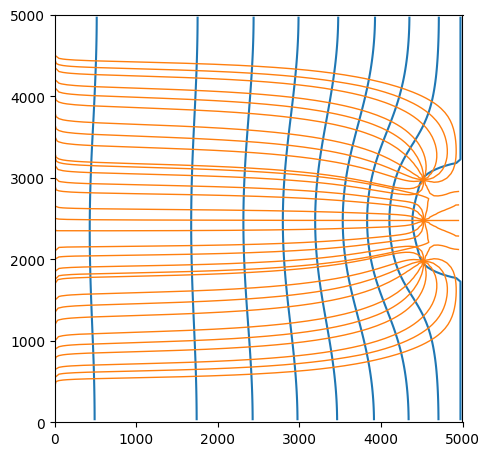

In [ ]:
#Read And Plot Pathlines​

pmv = fp.plot.PlotMapView(model=gwf)#create a map view plot of the groundwater flow model​
pmv.contour_array(head, levels=range(50,70), colors='C0') # add contours of the head distribution​
fname = os.path.join(modelws, f"{modelname}_abs_wells_bw.mppth") # path to the MODPATH output file ​
p = fp.utils.PathlineFile(fname) # read the pathline file​

for i in range(p.get_maxid() + 1): # loop over all particles​
    pi = p.get_data(partid=i) # get the pathline data for particle i​
    plt.plot(pi['x'], pi['y'], 'C1', lw =1) # plot the pathline of particle i​